In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt


In [16]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)

Train: (60000, 28, 28) (60000,)
Test : (10000, 28, 28) (10000,)


In [17]:
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Add channel dimension: (N, 28, 28) -> (N, 28, 28, 1)
x_train = x_train[..., tf.newaxis]
x_test  = x_test[..., tf.newaxis]

print("After preprocessing:")
print("Train:", x_train.shape)
print("Test :", x_test.shape)

After preprocessing:
Train: (60000, 28, 28, 1)
Test : (10000, 28, 28, 1)


### Visualizing Samples

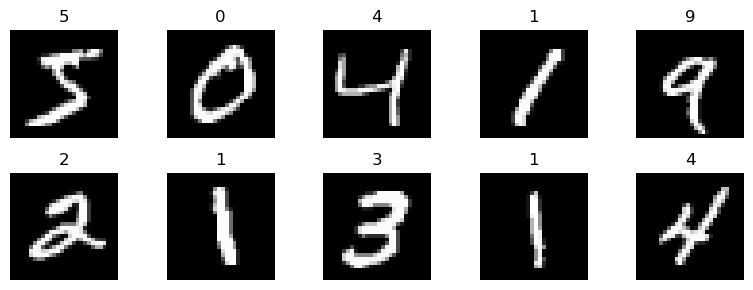

In [18]:
plt.figure(figsize=(8,3))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.title(int(y_train[i]))
    plt.axis("off")
plt.tight_layout()
plt.show()

In [19]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.08, 0.08),
], name="data_augmentation")

data_augmentation

<Sequential name=data_augmentation, built=False>

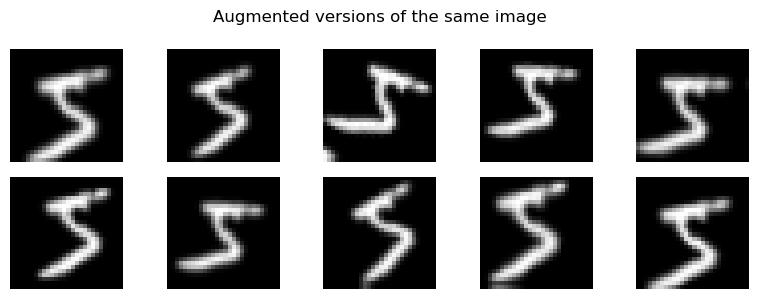

In [20]:
sample = x_train[0:1]  # one image

plt.figure(figsize=(8,3))
for i in range(10):
    augmented = data_augmentation(sample, training=True)
    plt.subplot(2,5,i+1)
    plt.imshow(augmented[0].numpy().squeeze(), cmap="gray")
    plt.axis("off")
plt.suptitle("Augmented versions of the same image")
plt.tight_layout()
plt.show()

In [21]:
model = keras.models.Sequential([
    keras.layers.Conv2D(32,(3,3), activation='relu',input_shape=(28,28,1)),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Dropout(0.25),

    keras.layers.Conv2D(64,(3,3), activation ='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Dropout(0.25),

    keras.layers.Flatten(),
    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10,activation='softmax')
])

c:\Users\Admin\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Compile & Train Model B

In [22]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=128,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 45ms/step - accuracy: 0.8860 - loss: 0.3670 - val_accuracy: 0.9769 - val_loss: 0.0715
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 36s 34ms/step - accuracy: 0.9643 - loss: 0.1192 - val_accuracy: 0.9851 - val_loss: 0.0439
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.9733 - loss: 0.0905 - val_accuracy: 0.9884 - val_loss: 0.0354
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 36ms/step - accuracy: 0.9782 - loss: 0.0734 - val_accuracy: 0.9888 - val_loss: 0.0324
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.9803 - loss: 0.0671 - val_accuracy: 0.9908 - val_loss: 0.0287


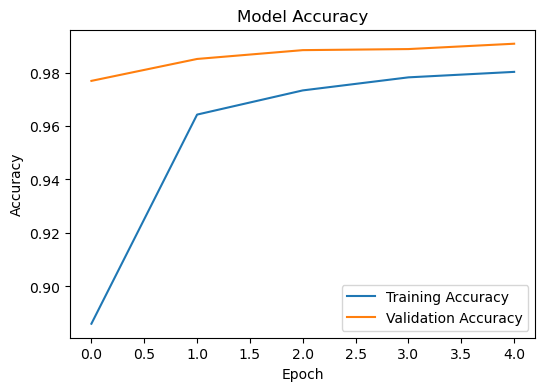

In [23]:

plt.figure(figsize=(6,4))

plt.plot(history.history['accuracy'],label="Training Accuracy")
plt.plot(history.history['val_accuracy'],label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")

plt.legend()

plt.show()

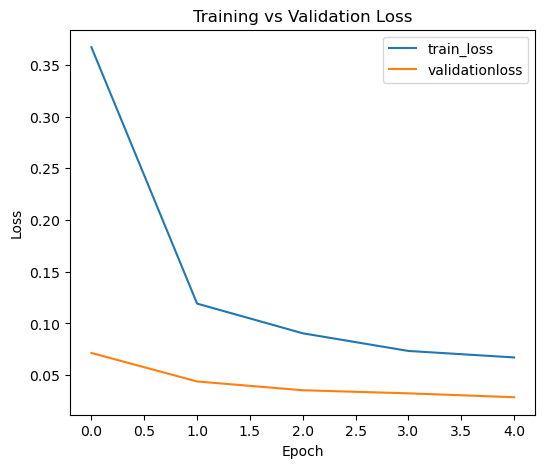

In [27]:

plt.figure(figsize=(6,5))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="validationloss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [25]:

total_loss,test_acc = model.evaluate(x_test,y_test)
print("Test accuracy: ", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9908 - loss: 0.0287
Test accuracy:  0.9908000230789185


Predictions using Model 


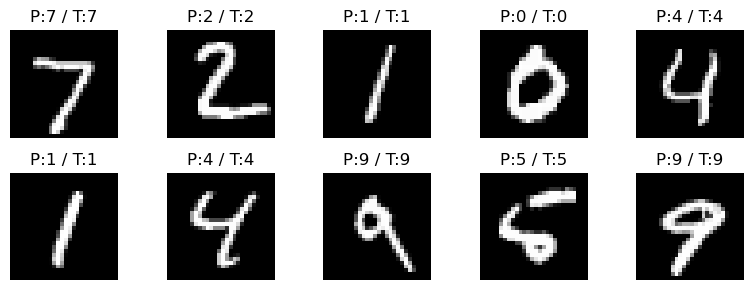

In [26]:
def show_predictions(model, x, y, n=10):
    preds = model.predict(x[:n], verbose=0)
    pred_labels = np.argmax(preds, axis=1)

    plt.figure(figsize=(8,3))
    for i in range(n):
        plt.subplot(2,5,i+1)
        plt.imshow(x[i].squeeze(), cmap="gray")
        plt.title(f"P:{pred_labels[i]} / T:{y[i]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

print("Predictions using Model ")
show_predictions(model, x_test, y_test, n=10)